# Bandit, Exploration and Exploitation

The goal of this exercise is to implement a simple bandit algorithm and test it on a simple environment. 

We will first start by understanding the problem. 

## 1. Understanding the Bandit Problem

In [3]:
import gymnasium as gym
import buffalo_gym

env = gym.make("Buffalo-v0", arms=3)
obs = env.reset()
count = 0
while count < 10:
    action = env.action_space.sample()
    obs, reward, terminated, truncated, info = env.step(action)
    print(f"Action: {action} - Reward: {reward}")
    count += 1
env.close()

Action: 2 - Reward: 4.132334543413502
Action: 0 - Reward: 10.377745605887315
Action: 2 - Reward: 3.6417068737518488
Action: 0 - Reward: 9.617556362484402
Action: 2 - Reward: 3.8336819147794534
Action: 2 - Reward: 3.9757421021460466
Action: 0 - Reward: 9.606004673750247
Action: 0 - Reward: 10.210307318582934
Action: 1 - Reward: 2.84672651859242
Action: 1 - Reward: 2.527401371927656


Answer the following questions:
1. What the code is doing?
2. What is the best option to take?
3. What is the expected reward of taking the best option?

## 2. Implementing an Incremental Update Rule

Complete the function `incremental_update` to implement the incremental update rule for the action-value estimates.

In [4]:
def incremental_update(Q, Times, action, reward):
    """
    Update the action-value estimate Q for the given action and reward using an incremental update rule.

    Parameters:
    Q (list): A list of action-value estimates for each action.
    Times (list): A list of counts of how many times each action has been taken.
    action (int): The index of the action taken.
    reward (float): The reward received after taking the action.

    Returns:
    list: Updated list of action-value estimates.
    """
    Q[action] = Q[action] + (reward - Q[action]) / (Times[action])

    return Q


And execute the following code to test your implementation:

In [5]:
import gymnasium as gym
import buffalo_gym

arms = 10
Q = [0.0 for _ in range(arms)]
Times = [0 for _ in range(arms)]
env = gym.make("Buffalo-v0", arms=arms)
obs = env.reset()
done = False
while not done:
    action = env.action_space.sample()
    obs, reward, terminated, truncated, info = env.step(action)
    print(f"Action: {action} - Reward: {reward}")
    Times[action] += 1
    Q = incremental_update(Q, Times, action, reward)
    done = terminated or truncated
env.close()

print("Final action-value estimates:", Q)

Action: 4 - Reward: 1.1405572678338642
Action: 3 - Reward: 4.423300100898933
Action: 3 - Reward: 3.196724202895011
Action: 9 - Reward: 0.6869034500959516
Action: 3 - Reward: 4.689270779384094
Action: 9 - Reward: 2.7447388921480167
Action: 0 - Reward: 10.22167918287001
Action: 6 - Reward: 4.856131756666032
Action: 5 - Reward: 0.3229462812411439
Action: 6 - Reward: 3.5230259600877263
Action: 0 - Reward: 10.73619695262652
Action: 7 - Reward: 2.6298683212302447
Action: 1 - Reward: 2.423989471169425
Action: 4 - Reward: 2.7479076392549695
Action: 6 - Reward: 4.797263535636383
Action: 2 - Reward: 3.0204081539136505
Action: 7 - Reward: 0.5357722512349506
Action: 4 - Reward: 4.029229401235791
Action: 7 - Reward: 0.3294229490179508
Action: 6 - Reward: 5.205174260025329
Action: 6 - Reward: 4.997772612261875
Action: 0 - Reward: 8.829422552248596
Action: 0 - Reward: 8.889805910319621
Action: 9 - Reward: 2.2737691884307734
Action: 4 - Reward: 2.82934833072653
Action: 4 - Reward: 3.1747481140564267
A

Questions: 
1. Which is the best action?
2. What is the expected reward of taking the best action?

## 3. Greedy Action Selection

Now that we have implemented the incremental update rule, we can implement a greedy action selection strategy.
Complete the function `greedy_action_selection` to implement a greedy action selection strategy.
This function will be replace the instruction `action = env.action_space.sample()` in the code above.

In [6]:
import numpy as np

# We don't want to use the argmax function from numpy because it doesn't break ties randomly. 
# We want to implement our own version of argmax that breaks ties randomly.

def argmax(q_values):
    """
    Takes in a list of q_values and returns the index of the item 
    with the highest value. Breaks ties randomly.
    returns: int - the index of the highest value in q_values
    """
    top_value = float("-inf")
    ties = []
    
    for i in range(len(q_values)):
        # if a value in q_values is greater than the highest value update top and reset ties to zero
        # if a value is equal to top value add the index to ties
        if q_values[i] > top_value:
            top_value = q_values[i]
            ties = []
            ties.append(i)
        elif q_values[i] == top_value:
            ties.append(i)
        
    # return a random selection from ties.
    return np.random.choice(ties)

In [7]:
# --------------
# Debugging Cell
# --------------
test_array = [0, 0, 0, 0, 0, 0, 0, 0, 1, 0]

assert argmax(test_array) == 8, "Check your argmax implementation returns the index of the largest value"

np.random.seed(0)
test_array = [1, 0, 0, 1]
assert argmax(test_array) == 0

In [8]:
def greedy_action_selection(Q):
    """
    Select an action using a greedy action selection strategy based on the action-value estimates Q.
    """

    return argmax(Q)

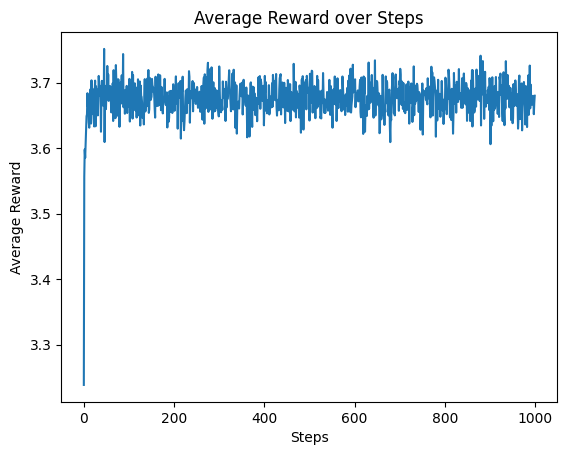

In [9]:
import gymnasium as gym
import buffalo_gym
import matplotlib.pyplot as plt

arms = 10
steps = 1000
runs = 2000

average_rewards = np.zeros(steps)

for run in range(runs):
    Q = [0.0 for _ in range(arms)]
    Times = [0 for _ in range(arms)]
    Rewards = [0.0 for _ in range(steps)]
    env = gym.make("Buffalo-v0", arms=arms)
    obs = env.reset()
    
    for step in range(steps):
        action = greedy_action_selection(Q)
        obs, reward, terminated, truncated, info = env.step(action)
        Times[action] += 1
        Q = incremental_update(Q, Times, action, reward)
        Rewards[step] = reward

    env.close()
    average_rewards += np.array(Rewards)

average_rewards /= runs

plt.plot(average_rewards)
plt.xlabel("Steps")
plt.ylabel("Average Reward")
plt.title("Average Reward over Steps")
plt.show()

Questions: 
1. Is the agent able to find the best action?
2. Are the rewards improving over time?

## 4. Epsilon-Greedy Action Selection

Complete the function `epsilon_greedy_action_selection` to implement an epsilon-greedy action selection strategy.

In [10]:
def epsilon_greedy_action_selection(Q, epsilon):
    """
    Select an action using an epsilon-greedy action selection strategy.
    """
    if np.random.rand() < epsilon:
        return np.random.randint(len(Q))
    else:
        return argmax(Q)

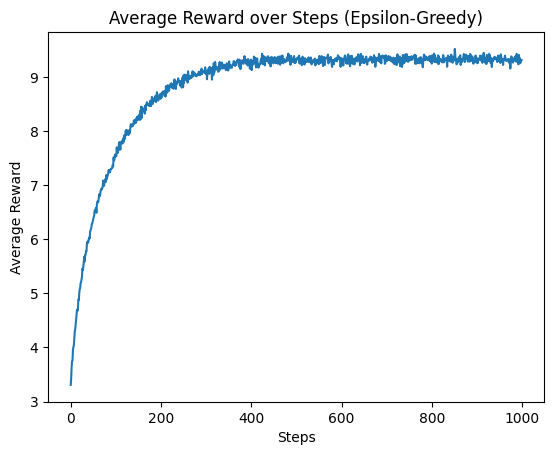

In [11]:
average_rewards_ep = np.zeros(steps)

for run in range(runs):
    Q = [0.0 for _ in range(arms)]
    Times = [0 for _ in range(arms)]
    Rewards = [0.0 for _ in range(steps)]
    env = gym.make("Buffalo-v0", arms=arms)
    obs = env.reset()
    
    for step in range(steps):
        action = epsilon_greedy_action_selection(Q, epsilon=0.1)
        obs, reward, terminated, truncated, info = env.step(action)
        Times[action] += 1
        Q = incremental_update(Q, Times, action, reward)
        Rewards[step] = reward

    env.close()
    average_rewards_ep += np.array(Rewards)

average_rewards_ep /= runs

plt.plot(average_rewards_ep)
plt.xlabel("Steps")
plt.ylabel("Average Reward")
plt.title("Average Reward over Steps (Epsilon-Greedy)")
plt.show()

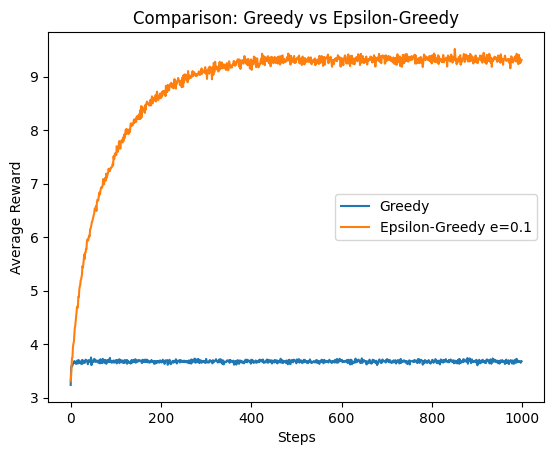

In [12]:
plt.plot(average_rewards, label="Greedy")
plt.plot(average_rewards_ep, label="Epsilon-Greedy e=0.1")
plt.xlabel("Steps")
plt.ylabel("Average Reward")
plt.title("Comparison: Greedy vs Epsilon-Greedy")
plt.legend()
plt.show()